# Model Fine Tuning and ROC Analysis

In this notebook we improve classification models using hyperparameter tuning.

Topics covered:

- ROC Curve
- ROC AUC
- Logistic Regression evaluation
- Hyperparameter tuning with GridSearchCV
- Hyperparameter tuning with RandomizedSearchCV

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
# Load Datase

df = pd.read_csv("../data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Feature Selection
features = ["Pclass","Age","Fare"]

X = df[features]

y = df["Survived"]

X = X.fillna(X.mean())

In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
# Train Logistic Regression
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [6]:
# Probability Predictions
y_prob = model.predict_proba(X_test)[:,1]

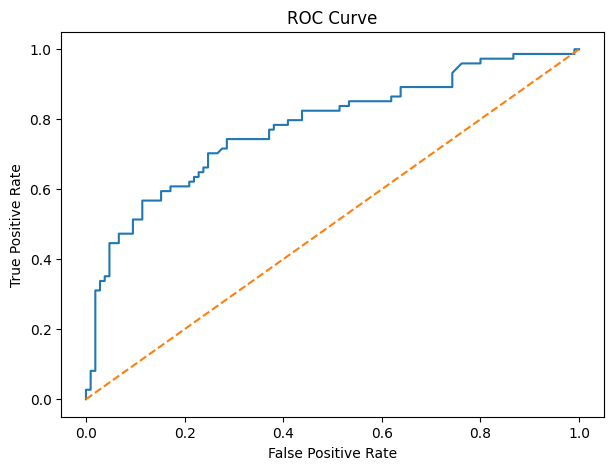

In [7]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [8]:
# ROC AUC Score

roc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_score)

ROC AUC: 0.7788288288288288


In [9]:
# GridSearchCV
# Tune hyperparameters
param_grid = {
    "C":[0.01,0.1,1,10,100]
}

# Grid search
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

# Best parameters
grid.best_params_

{'C': 0.1}

In [10]:
# RandomizedSearchCV

# Hyperparameter distribution
param_dist = {
    "C": np.logspace(-3,3,50)
}

# Randomized search
random_search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5
)

random_search.fit(X_train, y_train)

# Best parameters
random_search.best_params_


{'C': 0.03906939937054617}

In [11]:
# Compare Tuned Models

print("GridSearch Best Score:", grid.best_score_)
print("RandomizedSearch Best Score:", random_search.best_score_)

GridSearch Best Score: 0.6923766374470599
RandomizedSearch Best Score: 0.7021865458485177


## Key Insights

- ROC curve evaluates classification performance across thresholds.
- ROC AUC summarizes model performance.
- GridSearchCV systematically tests hyperparameters.
- RandomizedSearchCV samples hyperparameters randomly and is faster for large search spaces.